# Example: Multiple Linear Regression Estimating Fuel Efficiency

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_df = pd.read_csv('https://raw.githubusercontent.com/shreyamdg/automobile-data-set-analysis/refs/heads/master/cars.csv')
data_df.head()

,Unnamed: 0,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,3,2,164,audi,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,4,2,164,audi,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [3]:
data_df.columns

Index(['Unnamed: 0', 'symboling', 'normalized-losses', 'make', 'fuel-type',
       'aspiration', 'num-of-doors', 'body-style', 'drive-wheels',
       'engine-location', 'wheel-base', 'length', 'width', 'height',
       'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size',
       'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower',
       'peak-rpm', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')

In [4]:
columns_to_keep = data_df.columns[3:]
cars_df = data_df[columns_to_keep]

cars_df


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


## Exploratory Data Analysis



## Modeling

Can we estimate fuel economy from other car specifications?

In [5]:
cars_df = cars_df[cars_df['fuel-type']=='gas']
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               185 non-null    object 
 1   fuel-type          185 non-null    object 
 2   aspiration         185 non-null    object 
 3   num-of-doors       185 non-null    object 
 4   body-style         185 non-null    object 
 5   drive-wheels       185 non-null    object 
 6   engine-location    185 non-null    object 
 7   wheel-base         185 non-null    float64
 8   length             185 non-null    float64
 9   width              185 non-null    float64
 10  height             185 non-null    float64
 11  curb-weight        185 non-null    int64  
 12  engine-type        185 non-null    object 
 13  num-of-cylinders   185 non-null    object 
 14  engine-size        185 non-null    int64  
 15  fuel-system        185 non-null    object 
 16  bore               185 non-null

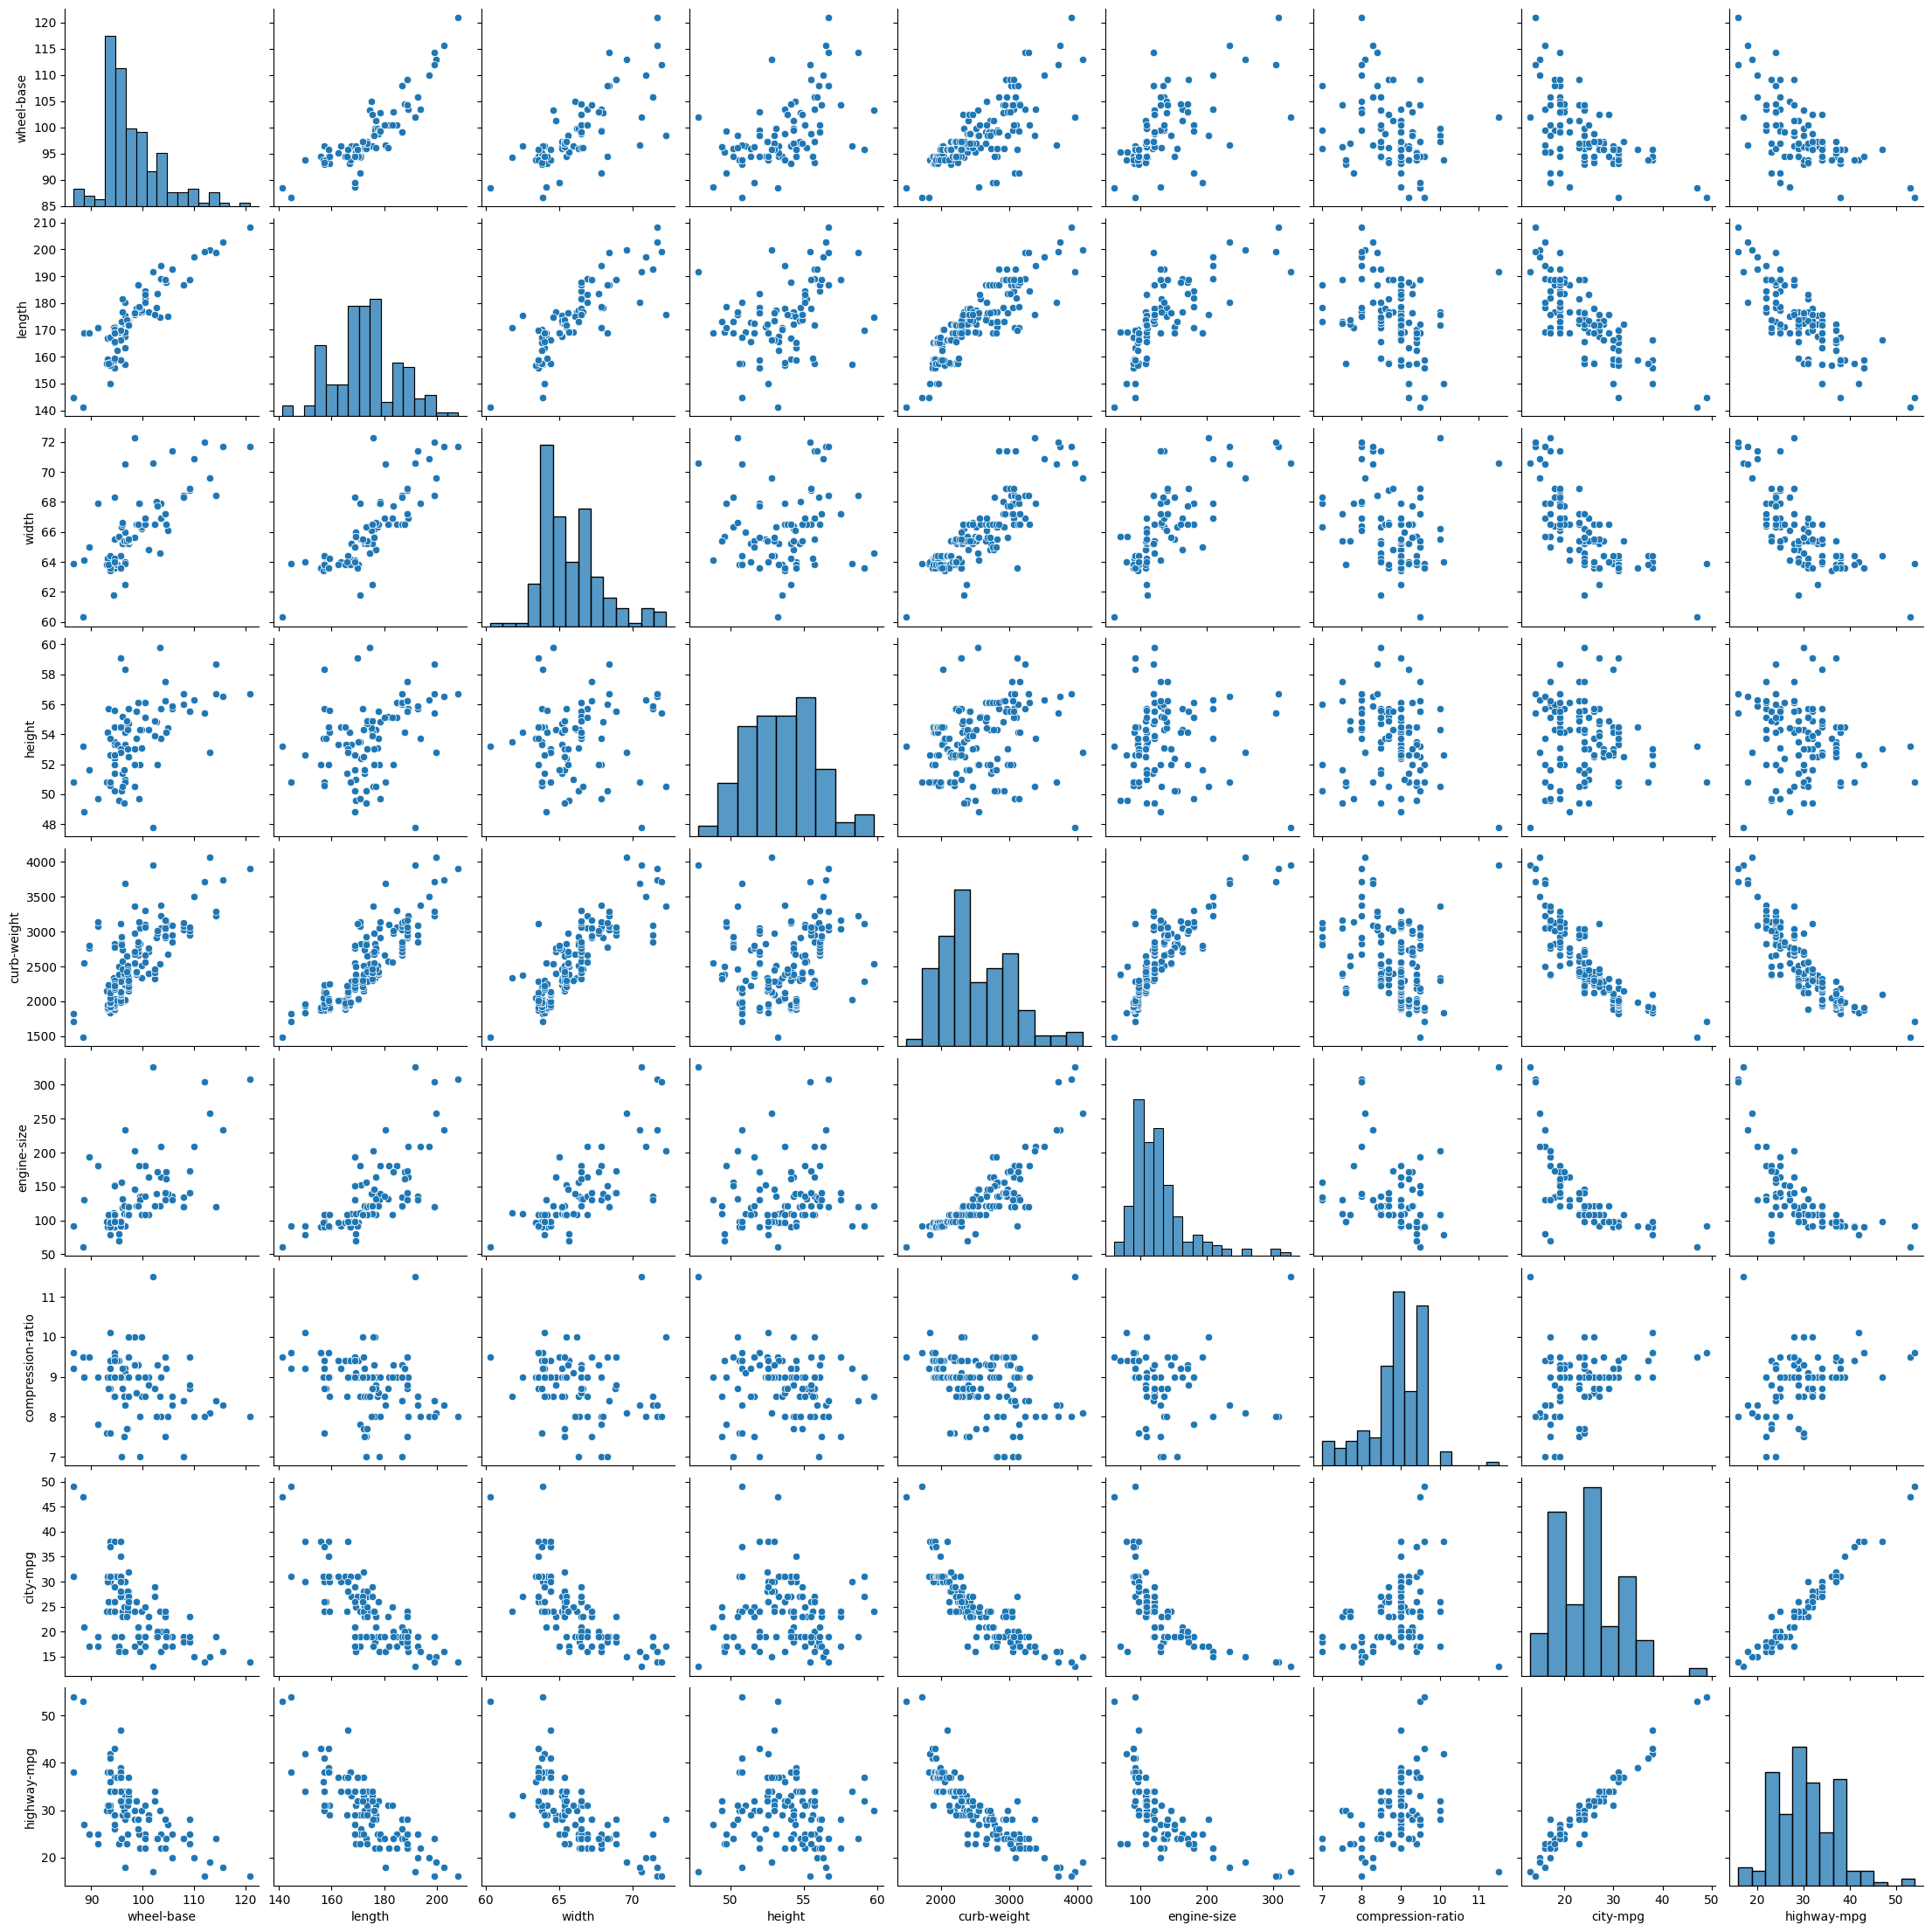

In [21]:
sns.pairplot(cars_df)
plt.show()

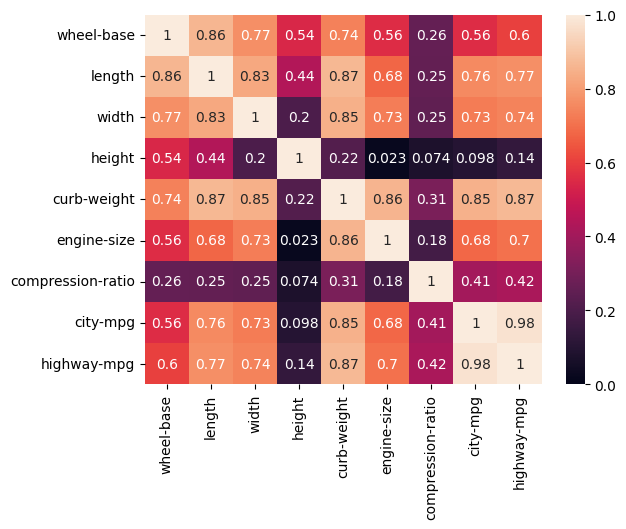

In [22]:
cars_corr = cars_df.corr(numeric_only=True)

sns.heatmap(np.abs(cars_corr), vmin = 0, vmax = 1, annot = True)
plt.show()

In [23]:
# Importing packages

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import root_mean_squared_error, r2_score

In [24]:
# Chose features from correlation heatmap
# curb-weight most correlated, and height and compression independent of curb-weight
features = ['curb-weight', 'height', 'compression-ratio']
target = ['city-mpg']

X = cars_df[features]
y = cars_df[target]

In [25]:
# Set aside data for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [26]:
# Normalize the data

sc = StandardScaler()

# Calculates mean and stdev of X_train
sc.fit(X_train)

Z_train = sc.transform(X_train)

# Choose our model type (linear regression) and fit the parameters
linreg = LinearRegression()

# This fit is where we get values for thetas (our parameters)
linreg.fit(Z_train, y_train)

linreg.__dict__


{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'n_features_in_': 3,
 'coef_': array([[-5.33928961,  0.43802736,  0.97023928]]),
 'rank_': 3,
 'singular_': array([14.93656822, 11.53493533,  9.37252349]),
 'intercept_': array([24.93243243])}

In [27]:
# Make predictions with the model

y_pred_train = linreg.predict(Z_train)

In [28]:
# Make predictions on our test data

Z_test = sc.transform(X_test)
y_pred_test = linreg.predict(Z_test)

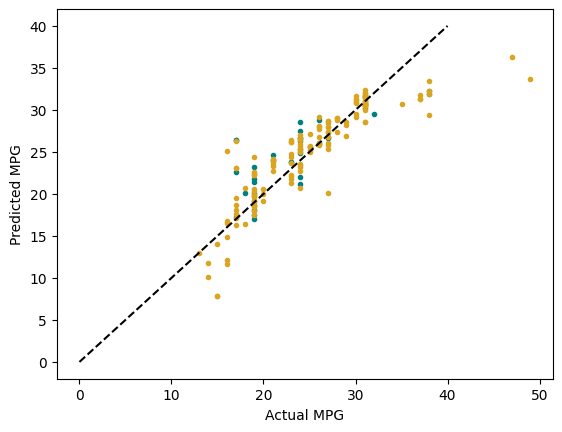

In [29]:
plt.plot(y_test, y_pred_test, '.', color = 'teal')
plt.plot(y_train, y_pred_train, '.', color = 'goldenrod')

plt.plot([0, 40], [0, 40], 'k--')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.show()